# NorthStar - Python Data Processing

This notebook is for the Python portion of the assignment. It imports the nine CSV files, cleans them, creates some additional columns that we are interested in for analysis, and creates a collection of charts. The cleaned CSVs are saved at the end so that the R and MongoDB notebooks can directly read them in.

Main jobs:
1. Load the raw data and audit it for quality issues
2. Fix the zone spelling problem and parse dates
3. Build derived columns (delivery duration, SLA breach flag, data integrity flags etc.)
4. Run the analysis to answer the case study's main questions
5. Produce charts for the report
6. Save the cleaned tables

## 1. Setup

The notebook loads the nine CSVs directly from this assignment's GitHub repository, so the marker can hit "Run all" without any upload step. If you want to run with local files instead, set `USE_LOCAL = True` and put the CSVs in a `data/` folder next to the notebook.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

# data is loaded from the GitHub repo so the notebook runs end-to-end without manual upload
# if running locally with the data folder next to the notebook, set USE_LOCAL = True
USE_LOCAL = False
BASE_URL  = "https://raw.githubusercontent.com/Daksh32146982/DBA-assignment/refs/heads/main/data"
LOCAL_DIR = Path('./data')

def csv_path(name):
    if USE_LOCAL and (LOCAL_DIR / f"{name}.csv").exists():
        return str(LOCAL_DIR / f"{name}.csv")
    return f"{BASE_URL}/{name}.csv"

CHART_DIR = Path('charts')
CLEAN_DIR = Path('cleaned_data')
for p in [CHART_DIR, CLEAN_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print('Data source:', 'local /data folder' if USE_LOCAL else 'GitHub')

Data source: GitHub


In [ ]:
# load all nine files from GitHub
files = ['hubs','vehicles','drivers','customers','orders',
         'deliveries','incidents','complaints','app_events']
raw = {f: pd.read_csv(csv_path(f)) for f in files}

for f, df in raw.items():
    print(f'{f:12s} {df.shape[0]:>5} rows, {df.shape[1]:>3} cols')

hubs             8 rows,   5 cols
vehicles       120 rows,   8 cols
drivers        170 rows,   8 cols
customers      650 rows,   9 cols
orders        1250 rows,  11 cols
deliveries     950 rows,  13 cols
incidents      280 rows,   7 cols
complaints     320 rows,  10 cols
app_events     640 rows,  10 cols


## 2. Data quality check

Three questions should be answered before cleaning: Are the foreign keys linked correctly? What are missing values? What is wrong with the categorical fields?

In [ ]:
# foreign key check - any orphan records?
def orphans(child, child_col, parent, parent_col):
    return len(set(child[child_col].dropna()) - set(parent[parent_col]))

checks = [
    ('orders.customer_id -> customers',     orphans(raw['orders'], 'customer_id', raw['customers'], 'customer_id')),
    ('deliveries.order_id -> orders',       orphans(raw['deliveries'], 'order_id', raw['orders'], 'order_id')),
    ('deliveries.driver_id -> drivers',     orphans(raw['deliveries'], 'driver_id', raw['drivers'], 'driver_id')),
    ('deliveries.vehicle_id -> vehicles',   orphans(raw['deliveries'], 'vehicle_id', raw['vehicles'], 'vehicle_id')),
    ('deliveries.hub_id -> hubs',           orphans(raw['deliveries'], 'hub_id', raw['hubs'], 'hub_id')),
    ('incidents.delivery_id -> deliveries', orphans(raw['incidents'], 'delivery_id', raw['deliveries'], 'delivery_id')),
    ('complaints.customer_id -> customers', orphans(raw['complaints'], 'customer_id', raw['customers'], 'customer_id')),
    ('complaints.order_id -> orders',       orphans(raw['complaints'], 'order_id', raw['orders'], 'order_id')),
    ('app_events.customer_id -> customers', orphans(raw['app_events'], 'customer_id', raw['customers'], 'customer_id')),
    ('app_events.order_id -> orders',       orphans(raw['app_events'], 'order_id', raw['orders'], 'order_id')),
]
for name, n in checks:
    print(f'{name:42s} orphans: {n}')

orders.customer_id -> customers            orphans: 0
deliveries.order_id -> orders              orphans: 0
deliveries.driver_id -> drivers            orphans: 0
deliveries.vehicle_id -> vehicles          orphans: 0
deliveries.hub_id -> hubs                  orphans: 0
incidents.delivery_id -> deliveries        orphans: 0
complaints.customer_id -> customers        orphans: 0
complaints.order_id -> orders              orphans: 0
app_events.customer_id -> customers        orphans: 0
app_events.order_id -> orders              orphans: 0


All keys are resolved cleanly. So it is not a fragmentation problem, as described in the case study, that the links are broken - the joins are working fine. Problems exist within the data.

In [ ]:
# missing values per file
miss = []
for f, df in raw.items():
    s = df.isna().sum()
    s = s[s > 0]
    for col, n in s.items():
        miss.append((f, col, int(n), round(n/len(df)*100, 1)))
pd.DataFrame(miss, columns=['file','column','nulls','pct_null']).sort_values('pct_null', ascending=False)

,file,column,nulls,pct_null
9,app_events,order_id,144,22.5
7,incidents,resolved_hours,17,6.1
8,complaints,compensation_amount,16,5.0
1,drivers,training_score,7,4.1
0,vehicles,battery_health_pct,4,3.3
2,customers,loyalty_score,20,3.1
5,deliveries,delivery_completed_at,19,2.0
4,orders,booking_channel,25,2.0
3,customers,preferred_channel,13,2.0
6,deliveries,customer_rating_post_delivery,14,1.5


In [ ]:
# zone columns - the README mentioned inconsistent categorical values
zone_cols = [('vehicles','assigned_zone'),('drivers','base_zone'),
             ('customers','home_zone'),('orders','pickup_zone'),
             ('orders','dropoff_zone'),('app_events','zone_context')]
for f, c in zone_cols:
    print(f'{f}.{c}: {raw[f][c].nunique()} unique')
    print(' ', sorted(raw[f][c].unique()))
    print()

vehicles.assigned_zone: 16 unique
  ['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

drivers.base_zone: 16 unique
  ['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

customers.home_zone: 16 unique
  ['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

orders.pickup_zone: 16 unique
  ['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

orders.dropoff_zone: 16 unique
  ['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

app_events.zone_context: 16 unique
  ['AIRPORT', 'Airpo

The number of "zones" is really 7 (North, South, East, West, Central, Airport, Riverside), but each has been spelt differently – with an upper case, a lower case, and "Ctr" for Central and "RiverSide" with an upper case S. This should be corrected; otherwise, any grouping at the zone level will be incorrect.

In [ ]:
# delivery timestamp sanity check
d_tmp = raw['deliveries'].copy()
d_tmp['dispatch_time']         = pd.to_datetime(d_tmp['dispatch_time'])
d_tmp['delivery_completed_at'] = pd.to_datetime(d_tmp['delivery_completed_at'])
d_tmp['duration']              = (d_tmp['delivery_completed_at'] - d_tmp['dispatch_time']).dt.total_seconds()/3600

print('Negative duration (completed before dispatch):', (d_tmp['duration']<0).sum())
print('OnTime but no completion timestamp:',
      ((d_tmp['delivery_status']=='OnTime') & d_tmp['delivery_completed_at'].isna()).sum())
print('Failed but customer rated:',
      ((d_tmp['delivery_status']=='Failed') & d_tmp['customer_rating_post_delivery'].notna()).sum())
print('Orders with no delivery:',
      len(set(raw['orders']['order_id']) - set(raw['deliveries']['order_id'])))

Negative duration (completed before dispatch): 64
OnTime but no completion timestamp: 12
Failed but customer rated: 131
Orders with no delivery: 300


Here are the true data challenges. 64 deliveries say they were completed before dispatched. There are 131 deliveries that have a rating from the customer, but failed. There were no orders with delivery records for 300 orders. These aren't spelling errors – they are the "system inconsistencies" that are described in the case study, where various components of NorthStar's database don't match.

## 3. Cleaning

### 3.1 Fix the zone column

One mapping function applied to all six columns that have zone values.

In [ ]:
# zone mapping
ZONE_MAP = {
    'north':'North','NORTH':'North','North':'North',
    'south':'South','SOUTH':'South','South':'South',
    'east':'East','EAST':'East','East':'East',
    'west':'West','WEST':'West','West':'West',
    'central':'Central','CENTRAL':'Central','Central':'Central',
    'ctr':'Central','Ctr':'Central','CTR':'Central',
    'airport':'Airport','AIRPORT':'Airport','Airport':'Airport',
    'riverside':'Riverside','RIVERSIDE':'Riverside','Riverside':'Riverside','RiverSide':'Riverside',
}

def canon_zone(s):
    if pd.isna(s): return np.nan
    return ZONE_MAP.get(str(s).strip(), str(s).strip().title())

clean = {k: v.copy() for k, v in raw.items()}

zone_targets = {'vehicles':['assigned_zone'], 'drivers':['base_zone'],
                'customers':['home_zone'], 'orders':['pickup_zone','dropoff_zone'],
                'app_events':['zone_context']}

for table, cols in zone_targets.items():
    for c in cols:
        before = clean[table][c].nunique()
        clean[table][c] = clean[table][c].apply(canon_zone)
        print(f'{table}.{c}: {before} -> {clean[table][c].nunique()} unique')

vehicles.assigned_zone: 16 -> 7 unique
drivers.base_zone: 16 -> 7 unique
customers.home_zone: 16 -> 7 unique
orders.pickup_zone: 16 -> 7 unique
orders.dropoff_zone: 16 -> 7 unique
app_events.zone_context: 16 -> 7 unique


### 3.2 Parse dates

In [ ]:
date_cols = {'vehicles':['commission_date'], 'customers':['signup_date'],
             'orders':['order_created_at'],
             'deliveries':['dispatch_time','delivery_completed_at'],
             'incidents':['reported_at'], 'complaints':['created_at'],
             'app_events':['event_timestamp']}

for table, cols in date_cols.items():
    for c in cols:
        clean[table][c] = pd.to_datetime(clean[table][c], errors='coerce')
print('dates parsed')

dates parsed


### 3.3 Handle missing values

There are some nulls in a few columns. Not all of the nulls are bad, some of them have significance. For instance, events that occurred before there were any orders will have null `app_events.order_id` which is not an issue. Same as `incidents.resolved_hours` being null when an incident is not resolved. I'm just assigning the null to where the column is required downstream, and the meaning of the null is not relevant to the analysis.


In [ ]:
# only impute where it makes sense
clean['customers']['preferred_channel'] = clean['customers']['preferred_channel'].fillna(
    clean['customers']['preferred_channel'].mode().iloc[0])

clean['customers']['loyalty_score'] = clean['customers']['loyalty_score'].fillna(
    clean['customers']['loyalty_score'].median())

clean['orders']['booking_channel'] = clean['orders']['booking_channel'].fillna('Unknown')

clean['complaints']['compensation_amount'] = clean['complaints']['compensation_amount'].fillna(0)

# everything else (battery_health_pct, training_score, delivery_completed_at,
# customer_rating_post_delivery, resolved_hours, app_events.order_id) keeps its NaN
# because the gap itself is useful information

print('missing values handled')

missing values handled


## 4. Feature engineering

Constructing columns that will be required during the analysis. The following integrity flags are most significant: they represent the inconsistencies that were found amongst the various system records described in the case study.


In [ ]:
d = clean['deliveries']

# how long the delivery actually took
d['duration_hours'] = (d['delivery_completed_at'] - d['dispatch_time']).dt.total_seconds()/3600

# integrity flags
d['negative_duration_flag'] = (d['duration_hours'] < 0).astype(int)
d['no_completion_flag']     = d['delivery_completed_at'].isna().astype(int)
d['ontime_no_completion']   = ((d['delivery_status']=='OnTime') & d['delivery_completed_at'].isna()).astype(int)
d['failed_but_rated']       = ((d['delivery_status']=='Failed') & d['customer_rating_post_delivery'].notna()).astype(int)
d['status_integrity_issue'] = ((d['negative_duration_flag']==1) |
                               (d['ontime_no_completion']==1) |
                               (d['failed_but_rated']==1)).astype(int)

# cost per km - useful for cost comparisons
d['cost_per_km'] = np.where(d['route_distance_km']>0,
                             d['fuel_or_charge_cost']/d['route_distance_km'], np.nan)

# time features
d['dispatch_month']   = d['dispatch_time'].dt.to_period('M').astype(str)
d['dispatch_weekday'] = d['dispatch_time'].dt.day_name()
d['dispatch_hour']    = d['dispatch_time'].dt.hour

print('delivery features done:', d.shape[1], 'columns now')

delivery features done: 23 columns now


In [ ]:
# order-level features - bring delivery info onto orders
o = clean['orders'].merge(
    d[['order_id','dispatch_time','delivery_status','duration_hours','status_integrity_issue']],
    on='order_id', how='left')

o['order_to_dispatch_hours'] = (o['dispatch_time'] - o['order_created_at']).dt.total_seconds()/3600
o['has_delivery']            = o['dispatch_time'].notna().astype(int)
o['total_elapsed_hours']     = o['order_to_dispatch_hours'].fillna(0) + o['duration_hours'].fillna(0)

# SLA breach: total time longer than the promised window
o['sla_breach'] = ((o['total_elapsed_hours'] > o['promised_window_hours']) & (o['has_delivery']==1)).astype(int)

print('order features done:', o.shape[1], 'columns now')

order features done: 19 columns now


In [ ]:
# link incidents to deliveries and complaints to orders
inc_per_delivery = clean['incidents'].groupby('delivery_id').size().rename('incident_count')
d = d.merge(inc_per_delivery, left_on='delivery_id', right_index=True, how='left')
d['incident_count'] = d['incident_count'].fillna(0).astype(int)
d['has_incident']   = (d['incident_count']>0).astype(int)

comp_per_order = clean['complaints'].groupby('order_id').size().rename('complaint_count')
o = o.merge(comp_per_order, left_on='order_id', right_index=True, how='left')
o['complaint_count'] = o['complaint_count'].fillna(0).astype(int)
o['has_complaint']   = (o['complaint_count']>0).astype(int)

clean['deliveries'] = d
clean['orders']     = o
print('linkage flags added')

linkage flags added


## 5. Analysis

Answering the series of questions raised by the case study. There were different ideas of what the problem was and the analysis below will examine each of those ideas.

### 5.1 Hub performance

The failures are due to the poor hubs, the operations director said. If that's correct then you should see that in the per-hub numbers.

In [ ]:
hubs = clean['hubs']
hub_perf = d.merge(hubs, on='hub_id').groupby(['hub_id','hub_name','hub_type','zone']).agg(
    deliveries=('delivery_id','count'),
    pct_ontime=('delivery_status', lambda x: (x=='OnTime').mean()*100),
    pct_delayed=('delivery_status', lambda x: (x=='Delayed').mean()*100),
    pct_failed=('delivery_status', lambda x: (x=='Failed').mean()*100),
    avg_duration=('duration_hours','mean'),
    avg_cost=('fuel_or_charge_cost','mean'),
    avg_override=('manual_route_override_count','mean'),
    incident_rate_pct=('has_incident', lambda x: x.mean()*100),
    integrity_issue_pct=('status_integrity_issue', lambda x: x.mean()*100),
).round(2).reset_index().sort_values('pct_failed', ascending=False)
hub_perf

,hub_id,hub_name,hub_type,zone,deliveries,pct_ontime,pct_delayed,pct_failed,avg_duration,avg_cost,avg_override,incident_rate_pct,integrity_issue_pct
7,H08,Midtown Relay,Charging,Central,128,62.50,17.19,20.31,9.82,11.71,1.11,25.00,27.34
4,H05,Central Core,Control,Central,115,58.26,21.74,20.00,10.90,13.69,0.95,29.57,24.35
5,H06,Airport Hub,Dispatch,Airport,104,59.62,25.96,14.42,9.38,13.32,0.91,24.04,23.08
3,H04,West Gate,Dispatch,West,127,65.35,22.05,12.60,10.33,13.17,0.87,25.98,20.47
0,H01,North Exchange,Dispatch,North,136,68.38,19.12,12.50,9.38,12.76,1.03,22.06,24.26
6,H07,Riverside Hub,Warehouse,Riverside,115,66.09,21.74,12.17,9.92,12.92,1.05,27.83,17.39
1,H02,South Link,Dispatch,South,106,66.04,24.53,9.43,8.87,12.57,0.92,28.30,16.98
2,H03,East Dock,Warehouse,East,119,71.43,19.33,9.24,7.66,12.74,0.89,26.89,19.33


The two hubs in the Central zone (Midtown Relay and Central Core) fail around 20% of the time. That is compared to the South Link and East Dock where the figures are around 9%. The ops director is correct in part, that performance on the hubs can vary quite significantly, but the problem is not a global route allocation problem, it is actually a local problem in one zone.

Another integrity test column in the data indicates that Midtown Relay has the highest percentage of deliveries with at least one data inconsistency (27%), which is also the highest in the network. Therefore, the poorest performing hub is also the one that has the worst records.

### 5.2 SLA breach by service type

The customer experience director believes that reliability is declining overall. The SLA breach flag we created is exactly that – is the total time greater than the time guaranteed?

In [ ]:
svc = o[o['has_delivery']==1].groupby('service_type').agg(
    orders=('order_id','count'),
    avg_value=('order_value','mean'),
    pct_sla_breach=('sla_breach', lambda x: x.mean()*100),
    pct_with_complaint=('has_complaint', lambda x: x.mean()*100),
).round(2).reset_index().sort_values('pct_sla_breach', ascending=False)
svc

,service_type,orders,avg_value,pct_sla_breach,pct_with_complaint
0,Business,126,97.45,71.43,22.22
3,Passenger,262,97.19,70.99,22.52
2,Parcel,230,90.15,70.43,21.30
1,Medical,108,86.53,66.67,19.44
4,Retail,224,86.81,62.95,23.21


The percentage of orders that violate the SLA varies between 63% and 71% for all service types. Business and Passenger are slightly worse, but it is a problem everywhere. Just one in five breaches is reported as a complaint – that's a lot of times that customers are having to wait without complaining.

### 5.3 Vehicle maintenance vs failure

This one was unexpected. Filtering deliveries by the vehicle's maintenance status shows a big gap.

In [ ]:
veh_perf = d.merge(clean['vehicles'], on='vehicle_id').groupby(['vehicle_type','maintenance_status']).agg(
    deliveries=('delivery_id','count'),
    pct_failed=('delivery_status', lambda x: (x=='Failed').mean()*100),
    incident_rate=('has_incident', lambda x: x.mean()*100),
    avg_cost=('fuel_or_charge_cost','mean'),
).round(2).reset_index()
veh_perf

,vehicle_type,maintenance_status,deliveries,pct_failed,incident_rate,avg_cost
0,CargoVan,Active,117,9.40,31.62,13.37
1,CargoVan,InRepair,68,32.35,23.53,12.46
2,CargoVan,Scheduled,38,13.16,15.79,11.88
3,Diesel,Active,80,10.00,20.00,12.43
4,Diesel,InRepair,55,30.91,36.36,13.30
5,Diesel,Scheduled,9,11.11,33.33,13.93
6,EV,Active,214,5.14,26.64,12.98
7,EV,InRepair,60,28.33,26.67,12.78
8,EV,Scheduled,65,3.08,30.77,12.88
9,Hybrid,Active,131,11.45,21.37,12.51


In [ ]:
# overall comparison
m = d.merge(clean['vehicles'], on='vehicle_id')
in_repair = m[m['maintenance_status']=='InRepair']
active    = m[m['maintenance_status']=='Active']
print(f'Deliveries on InRepair vehicles: {len(in_repair)} ({len(in_repair)/len(m)*100:.1f}% of all)')
print(f'  Fail rate when InRepair: {(in_repair["delivery_status"]=="Failed").mean()*100:.1f}%')
print(f'  Fail rate when Active:   {(active["delivery_status"]=="Failed").mean()*100:.1f}%')

Deliveries on InRepair vehicles: 254 (26.7% of all)
  Fail rate when InRepair: 30.3%
  Fail rate when Active:   8.3%


254 deliveries (27% of all of them) are being made by vehicles the maintenance system has marked as InRepair. About 30% of those vehicles fail as compared to 8% of Active vehicles. It's one of the most obvious trends that can be seen in the information. The maintenance status field exists but isn't being used as a dispatch gate - the dispatch system just picks the vehicle and goes.

### 5.4 Manual route overrides

In [ ]:
override_pivot = (pd.crosstab(d['manual_route_override_count'], d['delivery_status'], normalize='index')*100).round(2)
override_pivot

delivery_status,Delayed,Failed,OnTime
manual_route_override_count,,,
0,19.55,11.53,68.92
1,21.61,16.45,61.94
2,22.22,14.38,63.40
3,24.56,17.54,57.89
4,21.74,13.04,65.22
5,57.14,0.00,42.86
7,0.00,0.00,100.00


On-time rate decreases from 69% (no overrides) to approximately 58% (three overrides). The 5-override row only has 7 deliveries so I would ignore above 4, the numbers get small and noisy above 4. The pattern is not overdressy. But, most likely, it's drivers who are more likely to be violating when things aren't going well, not vice versa.

### 5.5 Worst-performing drivers

In [ ]:
drv_perf = d.groupby('driver_id').agg(
    deliveries=('delivery_id','count'),
    pct_failed=('delivery_status', lambda x: (x=='Failed').mean()*100),
    avg_rating=('customer_rating_post_delivery','mean'),
    avg_override=('manual_route_override_count','mean'),
).round(2)
drv_perf = drv_perf.merge(clean['drivers'][['driver_id','base_zone','employment_type','years_experience','training_score','driver_rating']],
                          left_index=True, right_on='driver_id').reset_index(drop=True)
drv_perf.nlargest(10, 'pct_failed')[['driver_id','base_zone','employment_type','years_experience','training_score','deliveries','pct_failed','avg_override']]

,driver_id,base_zone,employment_type,years_experience,training_score,deliveries,pct_failed,avg_override
50,D051,West,FullTime,3,75.4,2,100.00,2.00
62,D063,North,PartTime,12,85.7,3,66.67,0.33
91,D092,East,FullTime,15,88.2,5,60.00,0.40
103,D104,West,FullTime,15,87.7,7,57.14,1.71
23,D024,Riverside,PartTime,8,71.4,8,50.00,1.12
102,D103,Central,FullTime,15,72.5,4,50.00,1.50
110,D111,Airport,FullTime,15,79.2,4,50.00,0.50
131,D132,South,Contract,8,77.6,4,50.00,1.00
146,D147,West,FullTime,13,66.4,2,50.00,1.00
169,D170,West,FullTime,14,75.2,4,50.00,1.25


Not all drivers are to blame, but many are to blame for a lot of the failures. D051 has 100% failure rate with only 3 years experience and a 75 training score. Not all are inexperienced - D063 has 12 years, high training score. But training is not the only reason…

### 5.6 Revenue and cost by service

In [ ]:
od = o.merge(d[['order_id','fuel_or_charge_cost']], on='order_id', how='inner')
cost_by_svc = od.groupby('service_type').agg(
    orders=('order_id','count'),
    revenue=('order_value','sum'),
    cost=('fuel_or_charge_cost','sum'),
).round(2)
cost_by_svc['margin']     = (cost_by_svc['revenue'] - cost_by_svc['cost']).round(2)
cost_by_svc['margin_pct'] = (cost_by_svc['margin'] / cost_by_svc['revenue'] * 100).round(2)
cost_by_svc

,orders,revenue,cost,margin,margin_pct
service_type,,,,,
Business,126,12279.23,1655.91,10623.32,86.51
Medical,108,9344.88,1379.48,7965.40,85.24
Parcel,230,20735.44,3009.01,17726.43,85.49
Passenger,262,25463.36,3248.56,22214.80,87.24
Retail,224,19444.86,2906.27,16538.59,85.05


There is no problem on the surface margins - around 85% for all services. But this only counts fuel cost vs order value. It does not cover the cost of not delivering (fuel is used, money is not generated), compensation that is paid out or time spent on complaints. The finance director is right - costs do not appear in these numbers, you must know what happened in the exceptions system because it is a different system.

### 5.7 Complaints

In [ ]:
comp = clean['complaints']
comp_patterns = comp.groupby(['complaint_type','severity']).agg(
    count=('complaint_id','count'),
    avg_resolution_days=('resolution_days','mean'),
    avg_compensation=('compensation_amount','mean'),
).round(2).reset_index().sort_values('count', ascending=False)
comp_patterns.head(12)

,complaint_type,severity,count,avg_resolution_days,avg_compensation
11,Delay,Medium,56,5.96,17.23
17,MissedPickup,Medium,37,6.16,17.43
14,DriverBehaviour,Medium,31,5.42,15.36
10,Delay,Low,27,6.48,8.16
2,AppIssue,Medium,25,7.36,15.46
9,Delay,High,18,12.44,28.42
15,MissedPickup,High,16,11.56,43.07
12,DriverBehaviour,High,16,13.75,28.79
1,AppIssue,Low,15,6.07,12.37
0,AppIssue,High,13,13.92,31.43


Delay complaints is the most common (101 of 320). Damage complaints are the slowest to be resolved – 15+ days for high severity. The complex cases that involve photos, multi-party investigation and back and forth communication are the kind of cases that don't make sense in a fixed-schema table, making it an ideal fit for a document database.

### 5.8 Zone-level performance

In [ ]:
zone_perf = o[o['has_delivery']==1].groupby('pickup_zone').agg(
    orders=('order_id','count'),
    pct_sla_breach=('sla_breach', lambda x: x.mean()*100),
    pct_with_complaint=('has_complaint', lambda x: x.mean()*100),
).round(2).sort_values('pct_sla_breach', ascending=False)
zone_perf

,orders,pct_sla_breach,pct_with_complaint
pickup_zone,,,
Riverside,119,72.27,26.05
East,156,71.79,22.44
Central,174,70.69,21.26
Airport,113,69.03,20.35
West,114,65.79,14.91
South,139,64.75,23.02
North,135,64.44,25.19


The highest rates of SLA breach are in Riverside, East and Central (all >70%). North is interesting – higher complaints rate and lower breach rate – which is probably because customers in the region have higher expectations, so they complain when they don't get it.

### 5.9 Incident profile

In [ ]:
inc = clean['incidents']
inc_types = inc.groupby('incident_type').agg(
    count=('incident_id','count'),
    pct_critical=('severity', lambda x: (x=='Critical').mean()*100),
    pct_unresolved=('resolution_status', lambda x: x.isin(['Open','Escalated']).mean()*100),
    avg_resolved_hours=('resolved_hours','mean'),
).round(2).sort_values('count', ascending=False)
inc_types

,count,pct_critical,pct_unresolved,avg_resolved_hours
incident_type,,,,
ProofMissing,46,13.04,36.96,10.77
CustomerNoShow,44,11.36,36.36,13.89
RouteDeviation,43,9.30,46.51,13.73
VehicleFault,37,8.11,43.24,9.15
BatteryAlert,36,5.56,44.44,11.71
AppSyncError,31,3.23,32.26,12.66
TemperatureIssue,29,17.24,31.03,12.92
SafetyNearMiss,14,7.14,57.14,9.67


SafetyNearMiss is the highest with safety incidents being open or escalated over 57% of the time. It's a backlog issue that should be put up flagged. TemperatureIssue has the highest critical rate (17%) which matters for the cold-chain logistics service.

## 6. Charts

The charts below back up the findings in section 5. Each one is meant for the report.

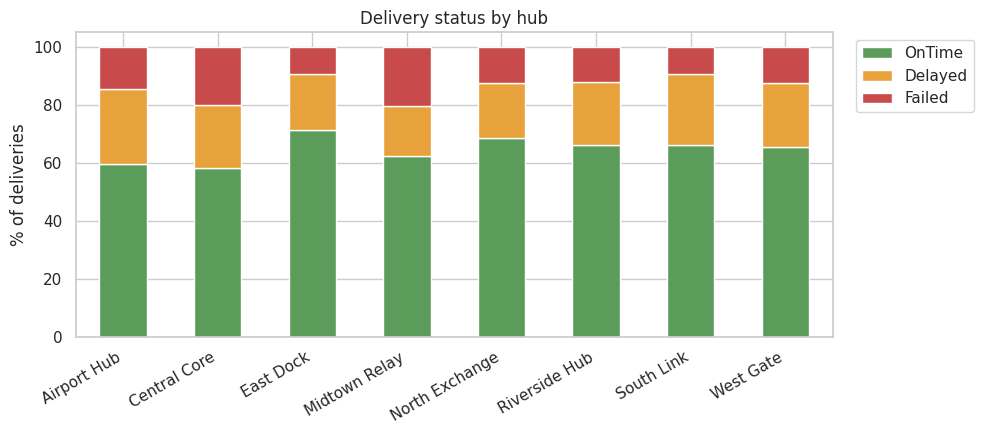

In [ ]:
# chart 1 - delivery status by hub
fig, ax = plt.subplots(figsize=(10, 4.5))
hs = d.merge(hubs[['hub_id','hub_name']], on='hub_id').groupby(['hub_name','delivery_status']).size().unstack(fill_value=0)
hs_pct = hs.div(hs.sum(axis=1), axis=0) * 100
hs_pct = hs_pct[['OnTime','Delayed','Failed']]
hs_pct.plot(kind='bar', stacked=True, ax=ax, color=['#5b9c5b','#e8a23c','#c84a4a'])
ax.set_title('Delivery status by hub')
ax.set_ylabel('% of deliveries')
ax.set_xlabel('')
ax.legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.savefig(CHART_DIR/'01_delivery_status_by_hub.png'); plt.show()

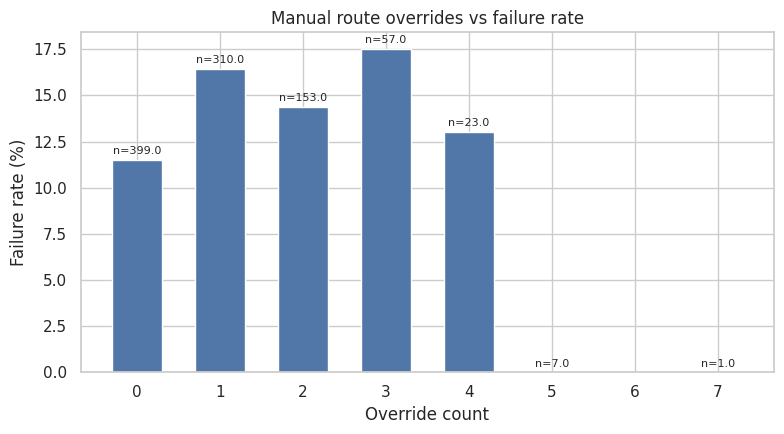

In [ ]:
# chart 2 - overrides vs failure rate
ov = d.groupby('manual_route_override_count').agg(
    n=('delivery_id','count'),
    fail_rate=('delivery_status', lambda x: (x=='Failed').mean()*100),
).reset_index()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(ov['manual_route_override_count'], ov['fail_rate'], color='#5077a8', width=0.6)
for i, row in ov.iterrows():
    ax.text(row['manual_route_override_count'], row['fail_rate']+0.3, f"n={row['n']}", ha='center', fontsize=8)
ax.set_title('Manual route overrides vs failure rate')
ax.set_xlabel('Override count')
ax.set_ylabel('Failure rate (%)')
plt.tight_layout(); plt.savefig(CHART_DIR/'02_overrides_vs_failure.png'); plt.show()

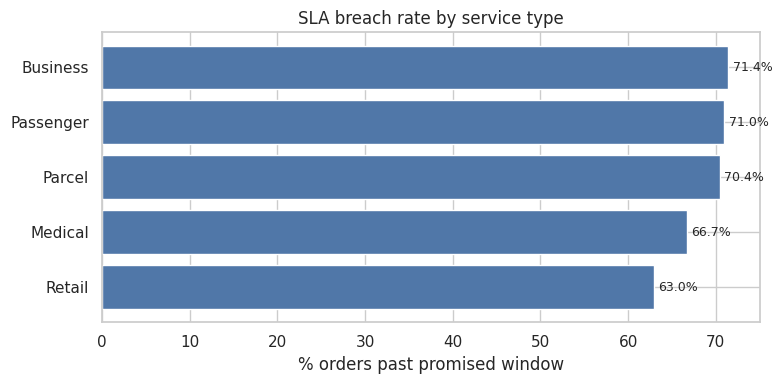

In [ ]:
# chart 3 - sla breach by service
ss = svc.sort_values('pct_sla_breach')
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(ss['service_type'], ss['pct_sla_breach'], color='#5077a8')
for i, row in ss.reset_index().iterrows():
    ax.text(row['pct_sla_breach']+0.5, i, f"{row['pct_sla_breach']:.1f}%", va='center', fontsize=9)
ax.set_title('SLA breach rate by service type')
ax.set_xlabel('% orders past promised window')
ax.set_ylabel('')
plt.tight_layout(); plt.savefig(CHART_DIR/'03_sla_breach_by_service.png'); plt.show()

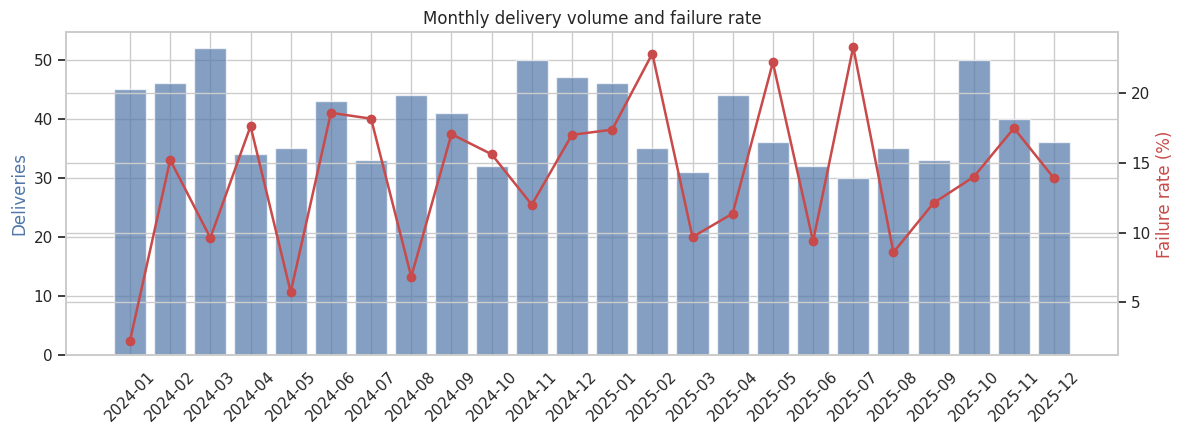

In [ ]:
# chart 4 - monthly volume and failure rate
monthly = d.groupby('dispatch_month').agg(
    deliveries=('delivery_id','count'),
    fail_rate=('delivery_status', lambda x: (x=='Failed').mean()*100),
).reset_index().sort_values('dispatch_month')

fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax1.bar(monthly['dispatch_month'], monthly['deliveries'], color='#5077a8', alpha=0.7)
ax1.set_ylabel('Deliveries', color='#5077a8'); ax1.tick_params(axis='x', rotation=45)
ax2 = ax1.twinx()
ax2.plot(monthly['dispatch_month'], monthly['fail_rate'], color='#c84a4a', marker='o', linewidth=1.8)
ax2.set_ylabel('Failure rate (%)', color='#c84a4a')
ax1.set_title('Monthly delivery volume and failure rate')
plt.tight_layout(); plt.savefig(CHART_DIR/'04_monthly_trend.png'); plt.show()

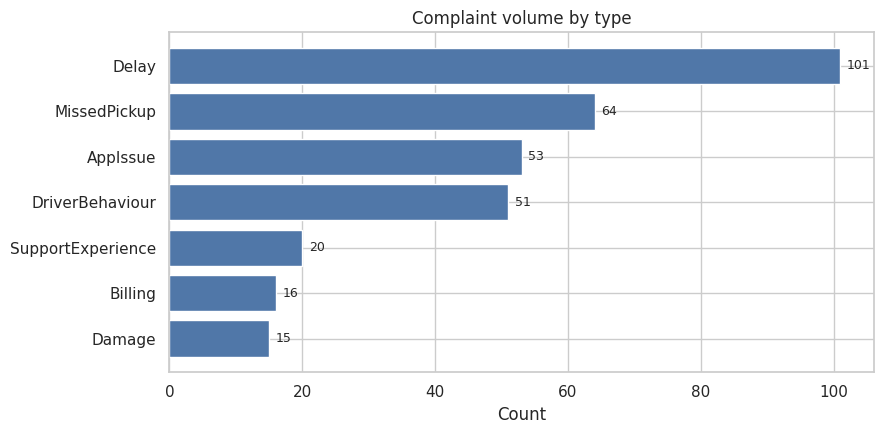

In [ ]:
# chart 5 - complaints by type
fig, ax = plt.subplots(figsize=(9, 4.5))
ct = comp['complaint_type'].value_counts().sort_values()
ax.barh(ct.index, ct.values, color='#5077a8')
for i, v in enumerate(ct.values):
    ax.text(v+1, i, str(v), va='center', fontsize=9)
ax.set_title('Complaint volume by type')
ax.set_xlabel('Count')
ax.set_ylabel('')
plt.tight_layout(); plt.savefig(CHART_DIR/'05_complaint_types.png'); plt.show()

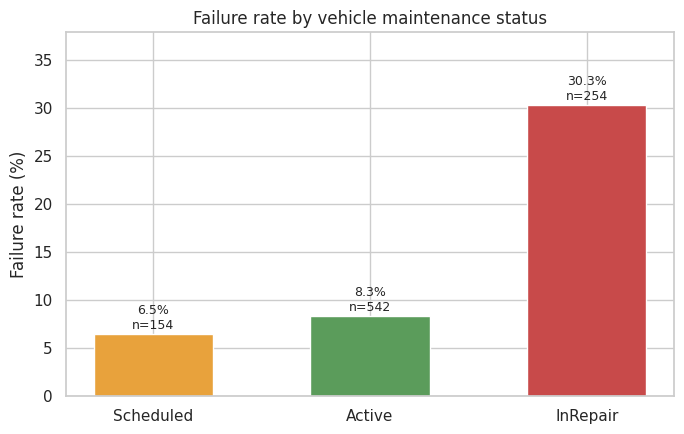

In [ ]:
# chart 6 - maintenance status vs failure
maint = d.merge(clean['vehicles'][['vehicle_id','maintenance_status']], on='vehicle_id')
mp = maint.groupby('maintenance_status').agg(
    deliveries=('delivery_id','count'),
    fail_rate=('delivery_status', lambda x: (x=='Failed').mean()*100),
).reset_index().sort_values('fail_rate')

fig, ax = plt.subplots(figsize=(7, 4.5))
colors_map = {'Active':'#5b9c5b','Scheduled':'#e8a23c','InRepair':'#c84a4a'}
bars = ax.bar(mp['maintenance_status'], mp['fail_rate'],
              color=[colors_map[s] for s in mp['maintenance_status']], width=0.55)
for bar, n, fr in zip(bars, mp['deliveries'], mp['fail_rate']):
    ax.text(bar.get_x()+bar.get_width()/2, fr+0.5, f"{fr:.1f}%\nn={n}", ha='center', fontsize=9)
ax.set_title('Failure rate by vehicle maintenance status')
ax.set_ylabel('Failure rate (%)')
ax.set_ylim(0, max(mp['fail_rate'])*1.25)
plt.tight_layout(); plt.savefig(CHART_DIR/'06_maintenance_vs_failure.png'); plt.show()

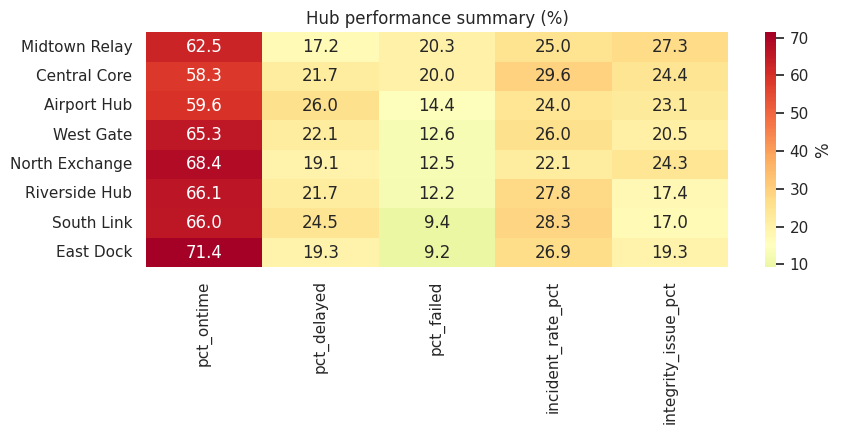

In [ ]:
# chart 7 - hub performance heatmap
hp = hub_perf.set_index('hub_name')[['pct_ontime','pct_delayed','pct_failed','incident_rate_pct','integrity_issue_pct']]
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(hp, annot=True, fmt='.1f', cmap='RdYlGn_r', center=15, ax=ax, cbar_kws={'label':'%'})
ax.set_title('Hub performance summary (%)')
ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout(); plt.savefig(CHART_DIR/'07_hub_kpi_heatmap.png'); plt.show()

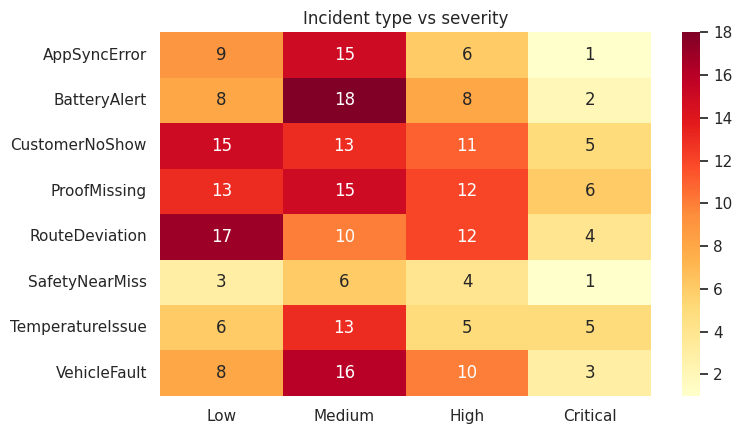

In [ ]:
# chart 8 - incident type x severity
heatmap = pd.crosstab(inc['incident_type'], inc['severity'])
heatmap = heatmap[['Low','Medium','High','Critical']]
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.heatmap(heatmap, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_title('Incident type vs severity')
ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout(); plt.savefig(CHART_DIR/'08_incident_heatmap.png'); plt.show()

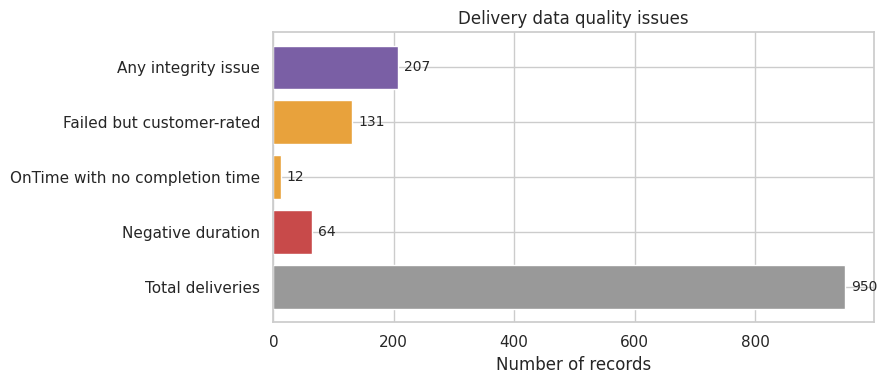

In [ ]:
# chart 9 - integrity issues summary
integrity = pd.Series({
    'Total deliveries': len(d),
    'Negative duration': int(d['negative_duration_flag'].sum()),
    'OnTime with no completion time': int(d['ontime_no_completion'].sum()),
    'Failed but customer-rated': int(d['failed_but_rated'].sum()),
    'Any integrity issue': int(d['status_integrity_issue'].sum()),
})
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#999999','#c84a4a','#e8a23c','#e8a23c','#7a5fa5']
ax.barh(integrity.index, integrity.values, color=colors)
for i, v in enumerate(integrity.values):
    ax.text(v+10, i, str(v), va='center', fontsize=10)
ax.set_title('Delivery data quality issues')
ax.set_xlabel('Number of records')
plt.tight_layout(); plt.savefig(CHART_DIR/'09_integrity_issues.png'); plt.show()

## 7. Save the cleaned data

Creating the cleaned tables as text files for easy reading by the R and MongoDB notebooks without having to redo the cleaning.

In [ ]:
for name, df in clean.items():
    out = CLEAN_DIR / f'{name}_clean.csv'
    df.to_csv(out, index=False)
    print(f'{out.name:30s} {df.shape[0]:>5} rows, {df.shape[1]:>3} cols')

hubs_clean.csv                     8 rows,   5 cols
vehicles_clean.csv               120 rows,   8 cols
drivers_clean.csv                170 rows,   8 cols
customers_clean.csv              650 rows,   9 cols
orders_clean.csv                1250 rows,  21 cols
deliveries_clean.csv             950 rows,  25 cols
incidents_clean.csv              280 rows,   7 cols
complaints_clean.csv             320 rows,  10 cols
app_events_clean.csv             640 rows,  10 cols


## 8. Summary

The data available to date:

Approximately 22% of deliveries contain at least one data integrity problem (duration of a delivery is negative, missing completion timestamp, or delivery failed with customer rating).

24% of orders are not completed or delivered to the order delivery system.
For InRepair vehicles, the failure rate of about 30% is higher than 8% for Active vehicles.

63% to 71% of orders are impacted by SLA breach in all service types. It's not restricted to a particular service.

Failure rates are about 20% for central zone hubs (Midtown Relay, Central Core), which are about 2X the number of the best hubs.

The surface margins look OK (85% plus), but they don't account for failure costs and compensation, which is why the finance director is right to be concerned about any hidden losses.

The cleaned CSVs are now stored and can be used for the next step. These will be utilized in the R notebook for SQL queries and statistical analysis, and the MongoDB notebook will be used to create the document collections.